# MIMIC NLP exploratory data analysis

This notebook inspects several MIMIC-IV tables housed locally under `physionet.org/files/`. All data are read without modification so the raw exports remain untouched.


## Setup


In [1]:

import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

pd.options.display.max_columns = 50
pd.options.display.float_format = lambda x: f"{x:,.2f}"
plt.style.use('ggplot')


In [2]:

BASE_DIR = Path('..')
PATHS = {
    'admissions': BASE_DIR / 'physionet.org' / 'files' / 'mimiciv' / '3.1' / 'hosp' / 'admissions.csv.gz',
    'patients': BASE_DIR / 'physionet.org' / 'files' / 'mimiciv' / '3.1' / 'hosp' / 'patients.csv.gz',
    'diagnoses_icd': BASE_DIR / 'physionet.org' / 'files' / 'mimiciv' / '3.1' / 'hosp' / 'diagnoses_icd.csv.gz',
    'discharge': BASE_DIR / 'physionet.org' / 'files' / 'mimic-iv-note' / '2.2' / 'note' / 'discharge.csv.gz',
    'events': BASE_DIR / 'physionet.org' / 'files' / 'mimic-iv-ext-22mcts' / '1.0.0' / 'clinical_event_timestamp.csv',
}

for name, path in PATHS.items():
    status = 'found' if path.exists() else 'missing'
    print(f"{name:<15} -> {path} ({status})")


admissions      -> ../physionet.org/files/mimiciv/3.1/hosp/admissions.csv.gz (found)
patients        -> ../physionet.org/files/mimiciv/3.1/hosp/patients.csv.gz (found)
diagnoses_icd   -> ../physionet.org/files/mimiciv/3.1/hosp/diagnoses_icd.csv.gz (found)
discharge       -> ../physionet.org/files/mimic-iv-note/2.2/note/discharge.csv.gz (found)
events          -> ../physionet.org/files/mimic-iv-ext-22mcts/1.0.0/clinical_event_timestamp.csv (found)


## Admissions table (mimiciv/3.1/hosp/admissions.csv.gz)


In [3]:

admissions_cols = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type',
    'admission_location', 'discharge_location', 'insurance', 'language',
    'marital_status', 'race', 'deathtime'
]
admissions = pd.read_csv(
    PATHS['admissions'],
    usecols=admissions_cols,
    parse_dates=['admittime', 'dischtime', 'deathtime']
).sort_values(['subject_id', 'admittime']).reset_index(drop=True)

admissions['length_of_stay_days'] = (admissions['dischtime'] - admissions['admittime']).dt.total_seconds() / 86400
admissions['next_admittime'] = admissions.groupby('subject_id')['admittime'].shift(-1)
admissions['days_to_next'] = (admissions['next_admittime'] - admissions['dischtime']).dt.total_seconds() / 86400
admissions['readmit_30d'] = admissions['days_to_next'].between(0, 30, inclusive='both')

admissions_summary = pd.Series({
    'rows': len(admissions),
    'unique_patients': admissions['subject_id'].nunique(),
    'median_los_days': admissions['length_of_stay_days'].median(),
    'percent_los_gt_7d': (admissions['length_of_stay_days'] > 7).mean(),
    'readmit_30d_rate': admissions['readmit_30d'].mean(),
    'in_hospital_mortality': admissions['deathtime'].notna().mean()
})
admissions_summary.to_frame('value')


,value
rows,"546,028.00"
unique_patients,"223,452.00"
median_los_days,2.82
percent_los_gt_7d,0.18
readmit_30d_rate,0.20
in_hospital_mortality,0.02


In [4]:

admission_type_counts = admissions['admission_type'].value_counts().to_frame('count')
admission_type_counts['percent'] = 100 * admission_type_counts['count'] / len(admissions)
admission_type_counts.head(10)


,count,percent
admission_type,,
EW EMER.,177459,32.50
EU OBSERVATION,119456,21.88
OBSERVATION ADMIT,84437,15.46
URGENT,54929,10.06
SURGICAL SAME DAY ADMISSION,42898,7.86
DIRECT OBSERVATION,24551,4.50
DIRECT EMER.,21973,4.02
ELECTIVE,13130,2.40
AMBULATORY OBSERVATION,7195,1.32


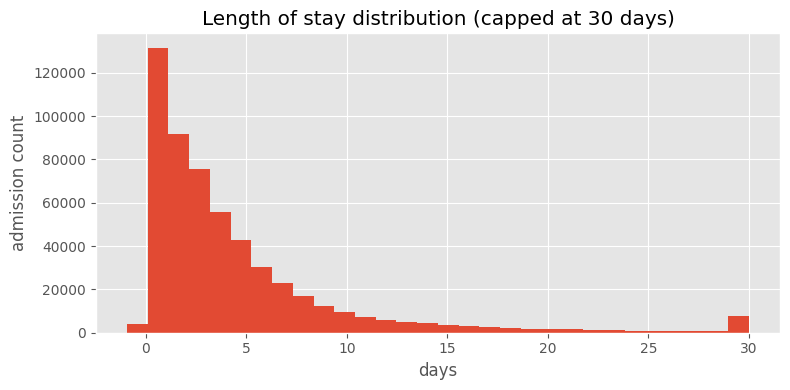

In [5]:

fig, ax = plt.subplots(figsize=(8, 4))
admissions['length_of_stay_days'].clip(upper=30).plot(kind='hist', bins=30, ax=ax)
ax.set_title('Length of stay distribution (capped at 30 days)')
ax.set_xlabel('days')
ax.set_ylabel('admission count')
fig.tight_layout()
plt.show()


In [6]:

readmit_by_type = admissions.groupby('admission_type')['readmit_30d'].agg(['count', 'mean']).rename(columns={'mean': 'readmit_30d_rate'})
readmit_by_type.sort_values('readmit_30d_rate', ascending=False).head(10)


,count,readmit_30d_rate
admission_type,,
DIRECT EMER.,21973,0.32
ELECTIVE,13130,0.30
OBSERVATION ADMIT,84437,0.21
EW EMER.,177459,0.21
DIRECT OBSERVATION,24551,0.20
EU OBSERVATION,119456,0.20
AMBULATORY OBSERVATION,7195,0.16
URGENT,54929,0.15
SURGICAL SAME DAY ADMISSION,42898,0.15


## Patient demographics (mimiciv/3.1/hosp/patients.csv.gz)


In [7]:

patients = pd.read_csv(PATHS['patients'])
patients_summary = pd.Series({
    'rows': len(patients),
    'unique_subjects': patients['subject_id'].nunique(),
    'percent_female': (patients['gender'] == 'F').mean(),
    'median_anchor_age': patients['anchor_age'].median(),
    'percent_age_ge_75': (patients['anchor_age'] >= 75).mean()
})
patients_summary.to_frame('value')


,value
rows,"364,627.00"
unique_subjects,"364,627.00"
percent_female,0.53
median_anchor_age,48.00
percent_age_ge_75,0.14


In [8]:

anchor_age_bins = pd.cut(
    patients['anchor_age'],
    bins=[18, 30, 45, 60, 75, 92],
    labels=['18-29', '30-44', '45-59', '60-74', '75-91'],
    right=False
)
age_bucket_counts = anchor_age_bins.value_counts().sort_index().to_frame('count')
age_bucket_counts['percent'] = 100 * age_bucket_counts['count'] / len(patients)
age_bucket_counts


,count,percent
anchor_age,,
18-29,91967,25.22
30-44,72766,19.96
45-59,77328,21.21
60-74,71171,19.52
75-91,51395,14.10


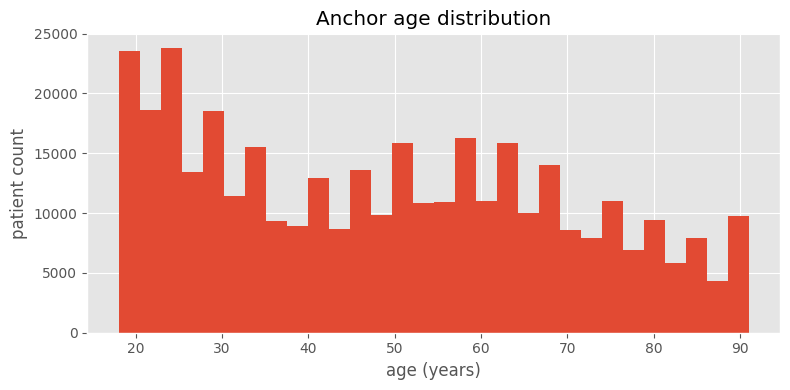

In [9]:

fig, ax = plt.subplots(figsize=(8, 4))
patients['anchor_age'].plot(kind='hist', bins=30, ax=ax)
ax.set_title('Anchor age distribution')
ax.set_xlabel('age (years)')
ax.set_ylabel('patient count')
fig.tight_layout()
plt.show()


In [10]:

admissions_with_demo = admissions.merge(
    patients[['subject_id', 'gender', 'anchor_age']],
    on='subject_id',
    how='left'
)
admissions_with_demo['age_band'] = pd.cut(
    admissions_with_demo['anchor_age'],
    bins=[18, 30, 45, 60, 75, 92],
    labels=['18-29', '30-44', '45-59', '60-74', '75-91'],
    right=False
)
age_readmit_summary = admissions_with_demo.groupby('age_band', observed=False).agg(
    admissions=('hadm_id', 'count'),
    median_los_days=('length_of_stay_days', 'median'),
    readmit_30d_rate=('readmit_30d', 'mean')
)
readmit_by_gender = admissions_with_demo.groupby('gender').agg(
    admissions=('hadm_id', 'count'),
    readmit_30d_rate=('readmit_30d', 'mean')
)
age_readmit_summary, readmit_by_gender


(          admissions  median_los_days  readmit_30d_rate
 age_band                                               
 18-29          59167             1.92              0.18
 30-44          86382             2.41              0.20
 45-59         138598             2.68              0.22
 60-74         152492             3.21              0.20
 75-91         109389             3.54              0.18,
         admissions  readmit_30d_rate
 gender                              
 F           284097              0.19
 M           261931              0.22)

## Diagnosis codes (mimiciv/3.1/hosp/diagnoses_icd.csv.gz)


In [11]:

diagnoses_sample = pd.read_csv(PATHS['diagnoses_icd'], nrows=5000)
diagnoses_sample.head()


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [12]:

chunksize = 500_000
total_rows = 0
code_counter = Counter()
prefix_counter = Counter()
version_counter = Counter()

for chunk in pd.read_csv(PATHS['diagnoses_icd'], usecols=['icd_code', 'icd_version'], chunksize=chunksize):
    codes = chunk['icd_code'].dropna().astype(str).str.strip().str.upper()
    total_rows += len(codes)
    code_counter.update(codes)
    prefix_counter.update(codes.str[:3])
    version_counter.update(chunk['icd_version'].dropna().astype(int))

icd_top_codes = (
    pd.DataFrame(code_counter.most_common(10), columns=['icd_code', 'count'])
    .assign(percent=lambda df: 100 * df['count'] / total_rows)
)
icd_top_prefix = (
    pd.DataFrame(prefix_counter.most_common(10), columns=['icd_prefix', 'count'])
    .assign(percent=lambda df: 100 * df['count'] / total_rows)
)
icd_version_share = (
    pd.DataFrame(sorted(version_counter.items()), columns=['icd_version', 'count'])
    .assign(percent=lambda df: 100 * df['count'] / total_rows)
)
icd_top_codes, icd_top_prefix, icd_version_share


(  icd_code   count  percent
 0     4019  102368     1.61
 1     E785   84570     1.33
 2      I10   83775     1.32
 3     2724   67293     1.06
 4   Z87891   62806     0.99
 5     K219   56157     0.88
 6    53081   48628     0.76
 7    25000   43077     0.68
 8     F329   41876     0.66
 9    I2510   41550     0.65,
   icd_prefix   count  percent
 0        401  106423     1.67
 1        E87   98689     1.55
 2        E78   97066     1.53
 3        Z79   90235     1.42
 4        E11   89083     1.40
 5        272   88179     1.39
 6        I10   83775     1.32
 7        250   78987     1.24
 8        V58   73196     1.15
 9        Z87   72866     1.14,
    icd_version    count  percent
 0            9  2908741    45.70
 1           10  3455747    54.30)

## Discharge summaries (mimic-iv-note/2.2/note/discharge.csv.gz)


In [13]:

discharge_sample = pd.read_csv(PATHS['discharge'], nrows=2000)
discharge_sample['char_len'] = discharge_sample['text'].str.len()
discharge_sample['word_count'] = discharge_sample['text'].str.split().str.len()
discharge_stats = discharge_sample[['char_len', 'word_count']].describe().T
missing_text_rate = discharge_sample['text'].isna().mean()
discharge_stats, missing_text_rate


(              count      mean      std    min      25%       50%       75%  \
 char_len   2,000.00 10,776.70 4,700.38 353.00 7,532.75 10,004.00 13,110.75   
 word_count 2,000.00  1,633.32   702.58  44.00 1,145.00  1,526.50  1,996.00   
 
                  max  
 char_len   43,717.00  
 word_count  5,966.00  ,
 np.float64(0.0))

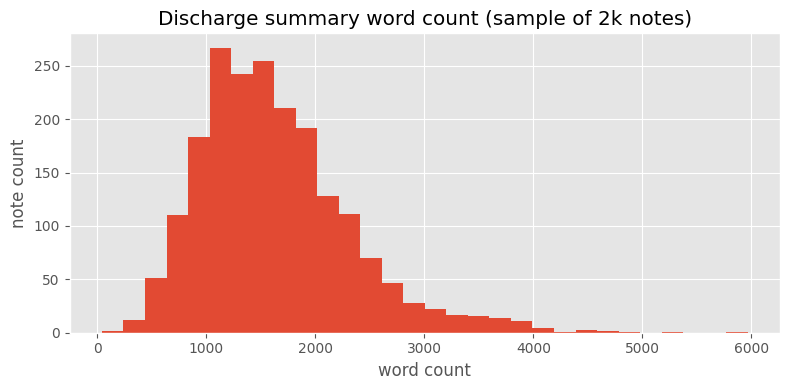

In [14]:

fig, ax = plt.subplots(figsize=(8, 4))
discharge_sample['word_count'].plot(kind='hist', bins=30, ax=ax)
ax.set_title('Discharge summary word count (sample of 2k notes)')
ax.set_xlabel('word count')
ax.set_ylabel('note count')
fig.tight_layout()
plt.show()


## Clinical event timestamps (mimic-iv-ext-22mcts/1.0.0/clinical_event_timestamp.csv)


In [15]:

events_sample = pd.read_csv(PATHS['events'], nrows=200000)
event_counts = events_sample['Event'].str.lower().value_counts().head(15).to_frame('count')
event_counts['percent'] = 100 * event_counts['count'] / len(events_sample)
time_summary = events_sample['Time'].describe()
time_bin_counts = events_sample['Time_bin'].value_counts().sort_index().to_frame('count')
event_counts, time_summary, time_bin_counts


(                                                count  percent
 Event                                                         
 hypertension                                     4540     2.27
 abdominal pain                                   2036     1.02
 fever                                            1935     0.97
 hypotension                                      1752     0.88
 chest pain                                       1517     0.76
 dress syndrome                                    940     0.47
 htn                                               878     0.44
 rash                                              772     0.39
 diarrhea                                          756     0.38
 pain                                              718     0.36
 diffuse erythematous or maculopapular eruption    696     0.35
 nausea                                            682     0.34
 adenosine                                         680     0.34
 eosinophilia                           

## Takeaways

- Admissions span roughly half a million stays across ~220k patients with a 20% 30-day readmission preview and notable variation by admission type.
- Patients skew middle-aged (median anchor age ~49); readmission rates peak for the 45-59 band and for male patients.
- Diagnosis coding leans slightly toward ICD-10 with hypertension and metabolic disorders dominating both precise codes and three-digit groupings.
- Discharge notes are long (median ~10k characters in the 2k-note sample) suggesting downstream NLP models must manage lengthy sequences.
- Event timestamp samples highlight hypertension, fever, and hypotension as the most common documented terms with dense activity near the admission time (Time 0).
